In [2]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")

pd.set_option("display.max_rows", 500)
pd.set_option("display.max_columns", 500)
pd.set_option("display.width", 1000)

# plotting style
plt.style.use("seaborn-v0_8")
sns.set_palette("husl")
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)

In [6]:
to_compare = ["kria_openssl", "kria_swtpm", "kria_tpm", "rpi_openssl", "rpi_swtpm", "ubuntu_openssl", "ubuntu_swtpm"]
processed_path = "./pipeline/data/processed_telemetry/"

combined_list = []
for file in to_compare:
    if "vm" in file or "ubuntu" in file:
        continue

    try:
        df = pd.read_csv(processed_path + f"{file}.csv")
        print(f"{file}: {df.shape}")

        dev, type_ = file.split("_")
        df["device"] = dev.replace("ubuntu", "vm")
        df["type"] = type_
        df["device_type"] = file.replace("ubuntu", "vm")

        combined_list.append(df)
    except FileNotFoundError:
        continue
    except Exception as err:
        print(str(err))

if combined_list:
    combined_df = pd.concat(combined_list).sort_values(
        by=["run", "timestamp", "integrity_check_enabled"], ignore_index=True
    )
else:
    combined_df = pd.DataFrame()

print(f"Combined: {combined_df.shape}")

kria_openssl: (63791, 6)
kria_swtpm: (63450, 6)
kria_tpm: (67903, 6)
rpi_openssl: (31710, 6)
rpi_swtpm: (31716, 6)
Combined: (258570, 9)


In [7]:
combined_df.head(15)

,run,timestamp,cpu_usage_percent,memory_used_mb,memory_usage_percent,integrity_check_enabled,device,type,device_type
0,1,2025-07-19 12:38:50.419,100.0,742,18.99,True,kria,swtpm,kria_swtpm
1,1,2025-07-19 12:38:50.428,100.0,743,19.00,True,kria,swtpm,kria_swtpm
2,1,2025-07-19 12:38:50.439,100.0,743,19.00,True,kria,swtpm,kria_swtpm
3,1,2025-07-19 12:38:50.448,100.0,743,19.00,True,kria,swtpm,kria_swtpm
4,1,2025-07-19 12:38:50.459,100.0,743,19.00,True,kria,swtpm,kria_swtpm
5,1,2025-07-19 12:38:50.469,100.0,743,19.00,True,kria,swtpm,kria_swtpm
6,1,2025-07-19 12:38:50.479,100.0,743,19.00,True,kria,swtpm,kria_swtpm
7,1,2025-07-19 12:38:50.489,100.0,743,19.00,True,kria,swtpm,kria_swtpm
8,1,2025-07-19 12:38:50.498,100.0,743,19.00,True,kria,swtpm,kria_swtpm
9,1,2025-07-19 12:38:50.509,100.0,743,19.00,True,kria,swtpm,kria_swtpm


In [10]:
summary_stats = (
    combined_df.groupby(["integrity_check_enabled"])
    .agg(
        {
            "cpu_usage_percent": ["mean", "std", "min", "max"],
            # "memory_used_mb": ["mean", "std", "min", "max"],
            "memory_usage_percent": ["mean", "std", "min", "max"],
        }
    )
    .round(2)
)
display(summary_stats)

summary_stats = (
    combined_df.groupby(["device_type", "integrity_check_enabled"])
    .agg(
        {
            "cpu_usage_percent": ["mean", "std", "min", "max"],
            # "memory_used_mb": ["mean", "std", "min", "max"],
            "memory_usage_percent": ["mean", "std", "min", "max"],
        }
    )
    .round(2)
)
display(summary_stats)

cpu_usage_percent                     memory_usage_percent                    
                                     mean    std   min    max                 mean   std    min    max
integrity_check_enabled                                                                               
False                               39.57  20.30  25.0  100.0                18.75  3.29  11.26  24.57
True                                37.42  20.23   0.0  100.0                18.68  3.19  11.53  24.72

cpu_usage_percent                       memory_usage_percent                    
                                                  mean    std    min     max                 mean   std    min    max
device_type  integrity_check_enabled                                                                                 
kria_openssl False                               39.32  21.43  25.00  100.00                20.72  1.37  18.37  24.57
             True                                38.66  21.14  22.82  100.00                20.71  1.38  18.21  24.72
kria_swtpm   False                               40.39  20.68  25.00  100.00                20.62  1.36  18.21  24.41
             True                                39.62  20.57  22.62  100.00                20.62  1.38  18.33  24.56
kria_tpm     False                               38.98  21.73  25.00  100.00                19.98  1.38  17.63  23.88
             True                                34.21  21.87   0.00  100.00                19.76  1.35  17.64  23.75
rpi_openssl  False                               39.62  16.98  25.00   80.48                13.19  1.00  11.26  16.90
             True                                37.70  16.35   7.14   77.11                13.87  1.42  11.53  19.56
rpi_swtpm    False                               39.60  16.55  25.00   78.78                13.60  0.96  12.06  17.06
             True                                37.54  16.34  23.10   77.11                13.55  1.00  11.86  17.44

In [11]:
wi_integrity = combined_df[combined_df["integrity_check_enabled"] == True]
woi_integrity = combined_df[combined_df["integrity_check_enabled"] == False]

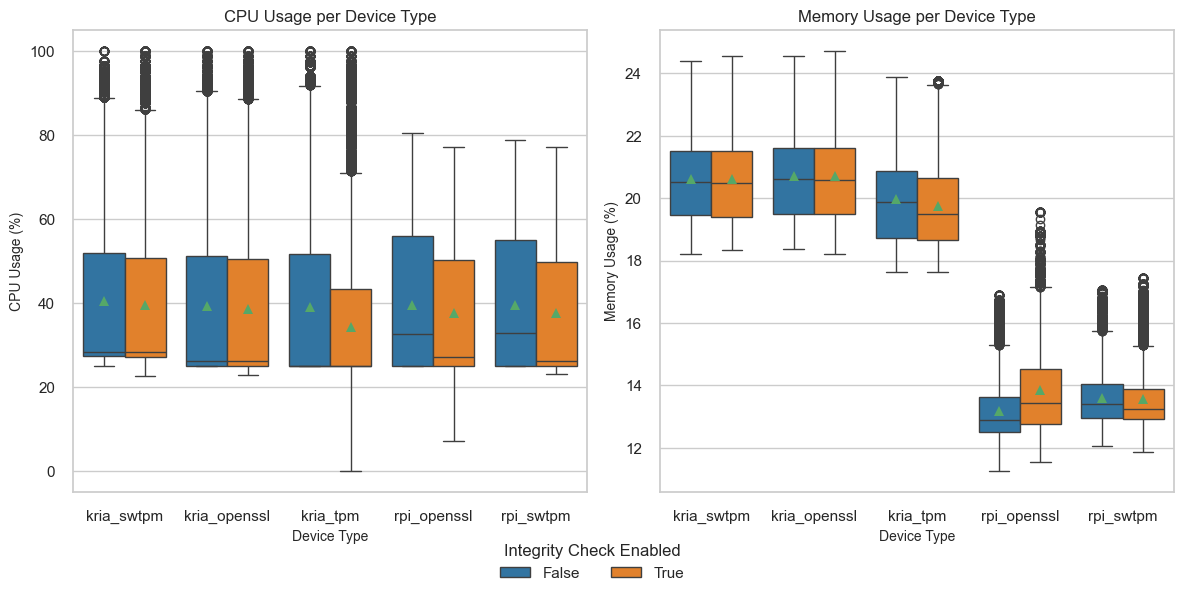

In [31]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6), sharey=False)

# CPU usage
sns.boxplot(
    data=combined_df,
    x="device_type",
    y="cpu_usage_percent",
    hue="integrity_check_enabled",
    palette="tab10",
    showmeans=True,
    meanprops={"markersize": 7},
    ax=axes[0],
)
axes[0].set_title("CPU Usage per Device Type", fontsize=12)
axes[0].set_xlabel("Device Type", fontsize=10)
axes[0].set_ylabel("CPU Usage (%)", fontsize=10)
axes[0].legend_.remove()

# memory usage
sns.boxplot(
    data=combined_df,
    x="device_type",
    y="memory_usage_percent",
    hue="integrity_check_enabled",
    palette="tab10",
    showmeans=True,
    meanprops={"markersize": 7},
    ax=axes[1],
)
axes[1].set_title("Memory Usage per Device Type", fontsize=12)
axes[1].set_xlabel("Device Type", fontsize=10)
axes[1].set_ylabel("Memory Usage (%)", fontsize=10)
axes[1].legend_.remove()

# single legend centred below both plots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="Integrity Check Enabled",
    loc="lower center",
    ncol=2,
    frameon=False,
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

In [9]:
# total processing time
with_integrity_total = wi_integrity["processing_time_ms"]
without_integrity_total = woi_integrity["inference_duration_ms"]

# summary
print("=== Processing Time ===")
with_integrity_mean = with_integrity_total.mean()
without_integrity_mean = without_integrity_total.mean()
time_overhead = with_integrity_mean - without_integrity_mean
time_overhead_pct = (time_overhead / without_integrity_mean) * 100

print(f"Average total processing time with integrity: {with_integrity_mean:.2f} ms")
print(f"Average total processing time without integrity: {without_integrity_mean:.2f} ms")
print(f"Time overhead from integrity check: {time_overhead:.2f} ms ({time_overhead_pct:.1f}%)")
print(f"Average integrity check duration: {wi_integrity['integrity_duration_ms'].mean():.2f} ms")

=== Processing Time ===
Average total processing time with integrity: 1327.29 ms
Average total processing time without integrity: 1174.62 ms
Time overhead from integrity check: 152.67 ms (13.0%)
Average integrity check duration: 148.66 ms
